# Part 1 - Simple Linear Regression 

## Do climate-related emotions (eco-anger/eco-anxiety/eco-depression/eco-hope) significantly predict engagement in pro-environmental activism in young people (CAB)?

In [10]:
# Cleaning of Hoggs et al Data 
# Raw data had different scales for different questions, the following code is standard-
# isation of these scales (based off of the codebook from the original paper).  

### Data Cleaning 

In [26]:
# Import modules
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import io
import requests

## Load dataframe
hoggs = pd.read_csv("Hogg_Data.csv")
hoggs.head(5)

,StartDate,EndDate,Attn1,Attn2,Efficacy1,Efficacy2,Efficacy3,Efficacy4,Efficacy5,Efficacy6,...,ECOANX_MEAN,ECOANG_MEAN,ECODEP_MEAN,ECOHOPE_MEAN,WORRY_MEAN,Mean_GenInJust,AFFECTIVE_MEAN,RUMINAT_MEAN,BEHAV_MEAN,PERSIM_MEAN
0,13885501670,13885502864,Strongly disagree,Nearly every day,Agree,Strongly agree,Agree,Agree,Agree,Agree,...,90.0,40.0,21.25,48.5,2.8,5.333333,0.5,Over half the days,Several of the days,2.3333333333333335
1,13885416088,13885416716,Strongly disagree,Nearly every day,Agree,Agree,Disagree,Agree,Slightly agree,Slightly agree,...,37.5,77.0,34.50,24.0,5.0,6.666667,Not at all,Not at all,Not at all,2.3333333333333335
2,13885504335,13885504822,Strongly disagree,Nearly every day,Slightly disagree,Strongly disagree,Slightly disagree,Slightly agree,Strongly disagree,Strongly disagree,...,0.0,100.0,25.00,0.0,1.4,7.000000,0.75,Not at all,1.6666666666666667,Not at all
3,13885501369,13885502215,Strongly disagree,Nearly every day,Agree,Slightly agree,Agree,Agree,Slightly agree,Neither agree nor disagree,...,100.0,100.0,95.00,22.5,3.4,7.000000,1.25,0.3333333333333333,Not at all,Not at all
4,13885507837,13885508265,Strongly disagree,Nearly every day,Slightly disagree,Slightly disagree,Slightly disagree,Slightly disagree,Slightly disagree,Slightly disagree,...,15.0,17.5,3.75,0.0,2.0,6.333333,Not at all,Not at all,2.3333333333333335,Not at all


In [27]:
# Replace all written descriptive answers with numerical scale

mapping = { 
    "Strongly disagree": 1,
    "Disagree": 2, 
    "Slightly disagree": 3, 
    "Neither agree nor disagree": 4, 
    "Slightly agree": 5, 
    "Agree": 6, 
    "Strongly agree": 7
}

hoggs = hoggs.replace(mapping)

In [28]:
mapping = { 
    "Not at all": 1,
    "Several of the days": 2, 
    "Over half the days": 3, 
    "Nearly every day": 4, 
}

hoggs = hoggs.replace(mapping)

In [29]:
mapping = { 
    "Not at all typical of me": 1,
    "Slightly typical of me": 2,     
    "Somewhat typical of me": 3,
    "Typical of me": 4,
    "Very typical of me": 5, 
}
hoggs = hoggs.replace(mapping)

In [30]:
# Remove unnecessary columns and replace with singular Participant number 
hoggs = hoggs.drop(columns=["StartDate", "EndDate"])
hoggs.head(5)

,Attn1,Attn2,Efficacy1,Efficacy2,Efficacy3,Efficacy4,Efficacy5,Efficacy6,CAB1,CAB2,...,ECOANX_MEAN,ECOANG_MEAN,ECODEP_MEAN,ECOHOPE_MEAN,WORRY_MEAN,Mean_GenInJust,AFFECTIVE_MEAN,RUMINAT_MEAN,BEHAV_MEAN,PERSIM_MEAN
0,1,4,6,7,6,6,6,6,1,0,...,90.0,40.0,21.25,48.5,2.8,5.333333,0.5,3,2,2.3333333333333335
1,1,4,6,6,2,6,5,5,0,0,...,37.5,77.0,34.50,24.0,5.0,6.666667,1,1,1,2.3333333333333335
2,1,4,3,1,3,5,1,1,0,0,...,0.0,100.0,25.00,0.0,1.4,7.000000,0.75,1,1.6666666666666667,1
3,1,4,6,5,6,6,5,4,0,0,...,100.0,100.0,95.00,22.5,3.4,7.000000,1.25,0.3333333333333333,1,1
4,1,4,3,3,3,3,3,3,0,0,...,15.0,17.5,3.75,0.0,2.0,6.333333,1,1,2.3333333333333335,1


In [31]:
hoggs.index = range(1, len(hoggs) + 1)
hoggs.index.name = "Participant"

hoggs.head()

,Attn1,Attn2,Efficacy1,Efficacy2,Efficacy3,Efficacy4,Efficacy5,Efficacy6,CAB1,CAB2,...,ECOANX_MEAN,ECOANG_MEAN,ECODEP_MEAN,ECOHOPE_MEAN,WORRY_MEAN,Mean_GenInJust,AFFECTIVE_MEAN,RUMINAT_MEAN,BEHAV_MEAN,PERSIM_MEAN
Participant,,,,,,,,,,,,,,,,,,,,,
1,1,4,6,7,6,6,6,6,1,0,...,90.0,40.0,21.25,48.5,2.8,5.333333,0.5,3,2,2.3333333333333335
2,1,4,6,6,2,6,5,5,0,0,...,37.5,77.0,34.50,24.0,5.0,6.666667,1,1,1,2.3333333333333335
3,1,4,3,1,3,5,1,1,0,0,...,0.0,100.0,25.00,0.0,1.4,7.000000,0.75,1,1.6666666666666667,1
4,1,4,6,5,6,6,5,4,0,0,...,100.0,100.0,95.00,22.5,3.4,7.000000,1.25,0.3333333333333333,1,1
5,1,4,3,3,3,3,3,3,0,0,...,15.0,17.5,3.75,0.0,2.0,6.333333,1,1,2.3333333333333335,1


In [32]:
# Replace gender with number 

level_mapping = {'Woman': 0, 'Man': 1, 'I prefer to self-describe:': 2}

gender_integer = hoggs['GenderNum'].copy()
gender_integer = gender_integer.replace(level_mapping)
gender_integer.head(5)

hoggs['gender_integer'] = gender_integer
gender_integer.head(10)

Participant
1     0
2     1
3     1
4     0
5     1
6     2
7     1
8     0
9     0
10    1
Name: GenderNum, dtype: int64

In [33]:
# Create dataframe that ignores participants outside of the inclusion criteria (18-30).
# This is for visualisation purposes, of eco-emotions and CAB association in young people from this data set 

hoggs_young = hoggs[(hoggs["Age"] >= 18) & (hoggs["Age"] <= 30)]
hoggs_young.head(5)

,Attn1,Attn2,Efficacy1,Efficacy2,Efficacy3,Efficacy4,Efficacy5,Efficacy6,CAB1,CAB2,...,ECOANG_MEAN,ECODEP_MEAN,ECOHOPE_MEAN,WORRY_MEAN,Mean_GenInJust,AFFECTIVE_MEAN,RUMINAT_MEAN,BEHAV_MEAN,PERSIM_MEAN,gender_integer
Participant,,,,,,,,,,,,,,,,,,,,,
2,1,4,6,6,2,6,5,5,0,0,...,77.00,34.5,24.0,5.0,6.666667,1,1,1,2.3333333333333335,1
3,1,4,3,1,3,5,1,1,0,0,...,100.00,25.0,0.0,1.4,7.000000,0.75,1,1.6666666666666667,1,1
7,1,4,7,7,7,7,7,6,20,0,...,5.00,32.5,15.0,1.6,5.333333,1.5,0.3333333333333333,1,1.3333333333333333,1
8,1,4,6,6,6,6,6,6,100,0,...,15.75,26.0,31.0,5.0,4.666667,1,1,2,1.3333333333333333,0
13,1,4,7,7,7,7,7,5,0,0,...,100.00,25.0,75.0,5.0,7.000000,0.75,2,1,2,1


### CAB_MEAN ~ ECOANG_MEAN

                            OLS Regression Results                            
Dep. Variable:               CAB_MEAN   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     45.24
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.77e-10
Time:                        16:36:19   Log-Likelihood:                -868.26
No. Observations:                 203   AIC:                             1741.
Df Residuals:                     201   BIC:                             1747.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      12.2681      2.138      5.737      

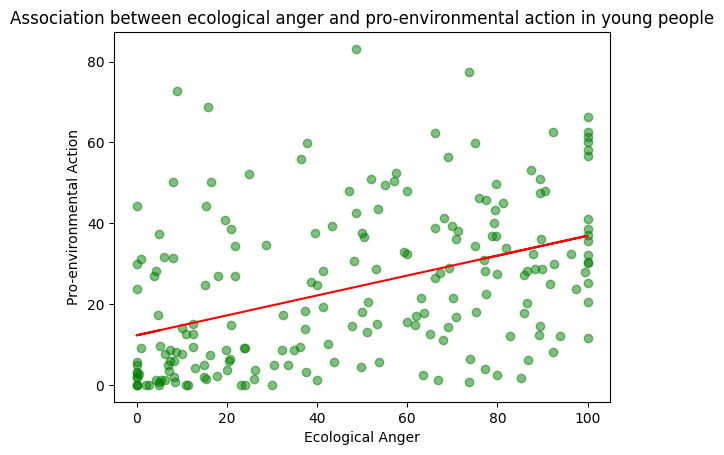

Intercept = 12.268054203729221
Slope = 0.2463349486070915
R-squared = 0.18372667701781542


In [34]:
import matplotlib.pyplot as plt

import statsmodels.api as sm

formula_string = "CAB_MEAN ~ ECOANG_MEAN"

model = sm.formula.ols(formula = formula_string, data = hoggs_young)
model_fitted = model.fit()

print(model_fitted.summary())

x = hoggs_young[["ECOANG_MEAN"]]
y = hoggs_young[["CAB_MEAN"]]

y_pred = model_fitted.predict(x)

plt.scatter(hoggs_young["ECOANG_MEAN"], hoggs_young["CAB_MEAN"], alpha = 0.5, color = "green")
plt.plot(hoggs_young["ECOANG_MEAN"], y_pred, color = 'red')
plt.xlabel("Ecological Anger")
plt.ylabel("Pro-environmental Action")
plt.title('Association between ecological anger and pro-environmental action in young people')
plt.show();


print('Intercept =', model_fitted.params.iloc[0])
print('Slope =', model_fitted.params.iloc[1])
print('R-squared =', model_fitted.rsquared)

$ y = 0.2463x + 12.2681 $

### CAB_MEAN ~ ECOANX_MEAN

                            OLS Regression Results                            
Dep. Variable:               CAB_MEAN   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     37.01
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           5.84e-09
Time:                        16:37:10   Log-Likelihood:                -871.71
No. Observations:                 203   AIC:                             1747.
Df Residuals:                     201   BIC:                             1754.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      10.8473      2.503      4.334      

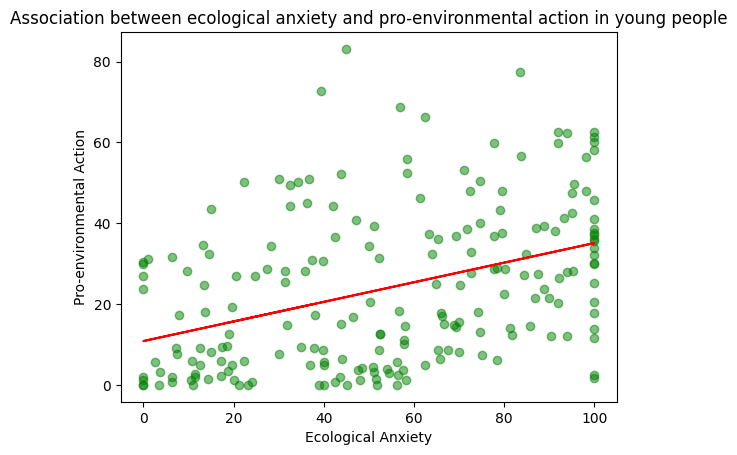

Intercept = 10.847346634951466
Slope = 0.2424592340809539
R-squared = 0.15549963554847213


In [35]:
formula_string = "CAB_MEAN ~ ECOANX_MEAN"

model = sm.formula.ols(formula = formula_string, data = hoggs_young)
model_fitted = model.fit()

print(model_fitted.summary())

x = hoggs_young[["ECOANX_MEAN"]]
y = hoggs_young[["CAB_MEAN"]]

y_pred = model_fitted.predict(x)

plt.scatter(hoggs_young["ECOANX_MEAN"], hoggs_young["CAB_MEAN"], alpha = 0.5, color = "green")
plt.plot(hoggs_young["ECOANX_MEAN"], y_pred, color = 'red')
plt.xlabel("Ecological Anxiety")
plt.ylabel("Pro-environmental Action")
plt.title('Association between ecological anxiety and pro-environmental action in young people')
plt.show();

print('Intercept =', model_fitted.params.iloc[0])
print('Slope =', model_fitted.params.iloc[1])
print('R-squared =', model_fitted.rsquared)

$ y = 0.2425x + 10.8473 $

### CAB_MEAN ~ ECODEP_MEAN

                            OLS Regression Results                            
Dep. Variable:               CAB_MEAN   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     38.05
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           3.72e-09
Time:                        16:37:39   Log-Likelihood:                -871.26
No. Observations:                 203   AIC:                             1747.
Df Residuals:                     201   BIC:                             1753.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      14.6412      1.969      7.437      

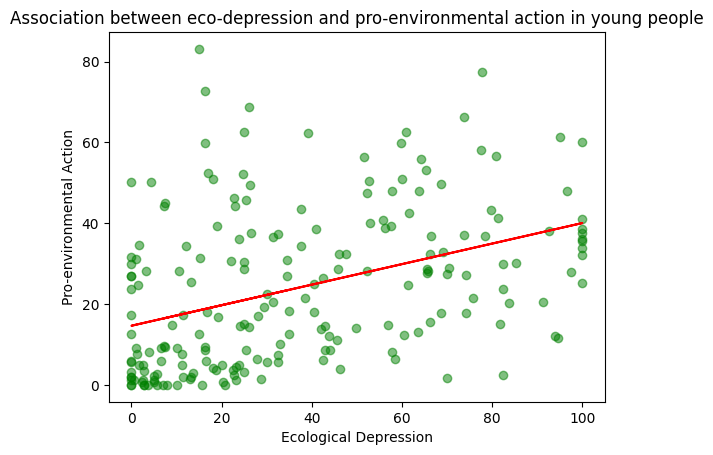

Intercept = 14.641202338272189
Slope = 0.2540666722620318
R-squared = 0.15918354126723322


In [36]:
formula_string = "CAB_MEAN ~ ECODEP_MEAN"

model = sm.formula.ols(formula = formula_string, data = hoggs_young)
model_fitted = model.fit()

print(model_fitted.summary())

x = hoggs_young[["ECODEP_MEAN"]]
y = hoggs_young[["CAB_MEAN"]]

y_pred = model_fitted.predict(x)

plt.scatter(hoggs_young["ECODEP_MEAN"], hoggs_young["CAB_MEAN"], alpha = 0.5, color = 'green')
plt.plot(hoggs_young["ECODEP_MEAN"], y_pred, color = 'red')
plt.xlabel("Ecological Depression")
plt.ylabel("Pro-environmental Action")
plt.title('Association between eco-depression and pro-environmental action in young people')
plt.show();


print('Intercept =', model_fitted.params.iloc[0])
print('Slope =', model_fitted.params.iloc[1])
print('R-squared =', model_fitted.rsquared)

$ y = 0.2541x + 14.6412 $

### CAB_MEAN ~ ECOHOPE_MEAN

                            OLS Regression Results                            
Dep. Variable:               CAB_MEAN   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     22.86
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           3.36e-06
Time:                        16:38:08   Log-Likelihood:                -877.93
No. Observations:                 203   AIC:                             1760.
Df Residuals:                     201   BIC:                             1766.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       17.2964      1.910      9.055   

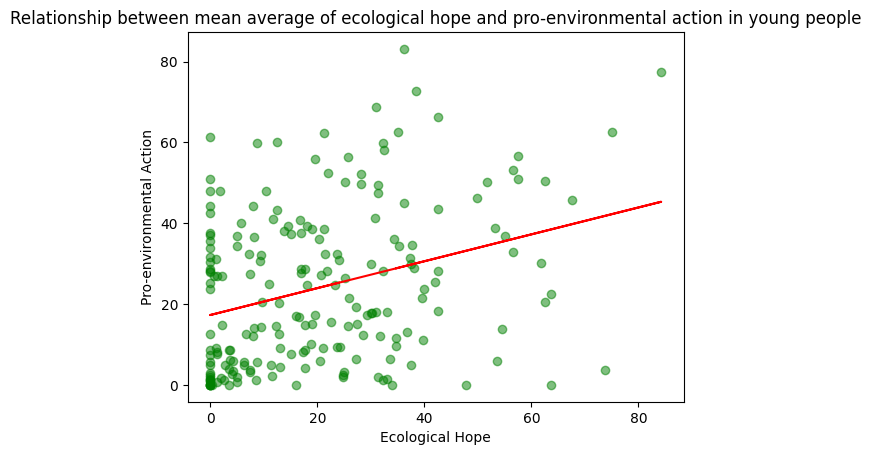

Intercept = 17.296370374378757
Slope = 0.332554227300623
R-squared = 0.10211993681849796


In [37]:
formula_string = "CAB_MEAN ~ ECOHOPE_MEAN"

model = sm.formula.ols(formula = formula_string, data = hoggs_young)
model_fitted = model.fit()

print(model_fitted.summary())

x = hoggs_young[["ECOHOPE_MEAN"]]
y = hoggs_young[["CAB_MEAN"]]

y_pred = model_fitted.predict(x)

plt.scatter(hoggs_young["ECOHOPE_MEAN"], hoggs_young["CAB_MEAN"], alpha = 0.5, color = 'green')
plt.plot(hoggs_young["ECOHOPE_MEAN"], y_pred, color = 'red')
plt.xlabel("Ecological Hope")
plt.ylabel("Pro-environmental Action")
plt.title('Relationship between mean average of ecological hope and pro-environmental action in young people')
plt.show();

print('Intercept =', model_fitted.params.iloc[0])
print('Slope =', model_fitted.params.iloc[1])
print('R-squared =', model_fitted.rsquared)

$ y = 0.3326x + 17.2964 $

# Part 2 - Multiple Linear Regression
## Do climate-related emotions (eco-anger/eco-anxiety/eco-depression/eco-hope) significantly predict engagement in pro-environmental activism (CAB) when examined simultaneously alongside other predictors such as efficacy, age and gender?

In [40]:
hoggs['EFFICACY_MEAN'] = hoggs['EFFICACY_MEAN'].astype(float)

formula_string = "CAB_MEAN ~ ECOANG_MEAN + ECOANX_MEAN + ECODEP_MEAN + ECOHOPE_MEAN"

model = sm.formula.ols(formula = formula_string, data = hoggs)
model_fitted = model.fit()

print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:               CAB_MEAN   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     54.39
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           4.24e-38
Time:                        16:41:40   Log-Likelihood:                -2127.8
No. Observations:                 508   AIC:                             4266.
Df Residuals:                     503   BIC:                             4287.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.4782      1.383      3.239   

In [41]:
hoggs['EFFICACY_MEAN'] = hoggs['EFFICACY_MEAN'].astype(float)

formula_string = "CAB_MEAN ~ ECOANG_MEAN + ECOANX_MEAN + ECODEP_MEAN + ECOHOPE_MEAN + EFFICACY_MEAN + Age + GenderNum"

model = sm.formula.ols(formula = formula_string, data = hoggs)
model_fitted = model.fit()

print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:               CAB_MEAN   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     30.76
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           3.58e-39
Time:                        16:41:53   Log-Likelihood:                -2117.2
No. Observations:                 508   AIC:                             4252.
Df Residuals:                     499   BIC:                             4291.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.3851      5